In [2]:
# Task 2: Multi-Modal Cardiac Image Fusion
# Put aligned slices at: data/ct.png and data/mri.png

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

CT_PATH = "data/ct.png"
MRI_PATH = "data/mri.png"
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
def log_transform(image):
    image_float = image.astype(np.float32)
    c = 255 / np.log1p(np.max(image_float))
    return np.uint8(np.clip(c * np.log1p(image_float), 0, 255))


def power_law_transform(image, gamma=0.9):
    return np.uint8(255 * (image / 255.0) ** gamma)


ct = cv2.imread(CT_PATH, cv2.IMREAD_GRAYSCALE)
mri = cv2.imread(MRI_PATH, cv2.IMREAD_GRAYSCALE)

if ct is None:
    raise FileNotFoundError(f"CT image not found: {CT_PATH}")
if mri is None:
    raise FileNotFoundError(f"MRI image not found: {MRI_PATH}")

# Matching aligned images must have identical dimensions.
if ct.shape != mri.shape:
    mri = cv2.resize(mri, (ct.shape[1], ct.shape[0]))
    print("MRI resized to match the CT dimensions.")

In [4]:
# 1. Equalize each modality independently
ct_equalized = cv2.equalizeHist(ct)
mri_equalized = cv2.equalizeHist(mri)

# 2. Convert enhanced scans to different heatmaps
ct_color = cv2.applyColorMap(ct_equalized, cv2.COLORMAP_BONE)
mri_color = cv2.applyColorMap(mri_equalized, cv2.COLORMAP_JET)

# 3. Weighted fusion: heavier CT weight preserves structural edges
alpha = 0.65
beta = 0.35
fused = cv2.addWeighted(ct_color, alpha, mri_color, beta, 0)

# 4. Log and power-law transformations on final fused matrix
fused_log = log_transform(fused)
fused_final = power_law_transform(fused_log, gamma=0.9)

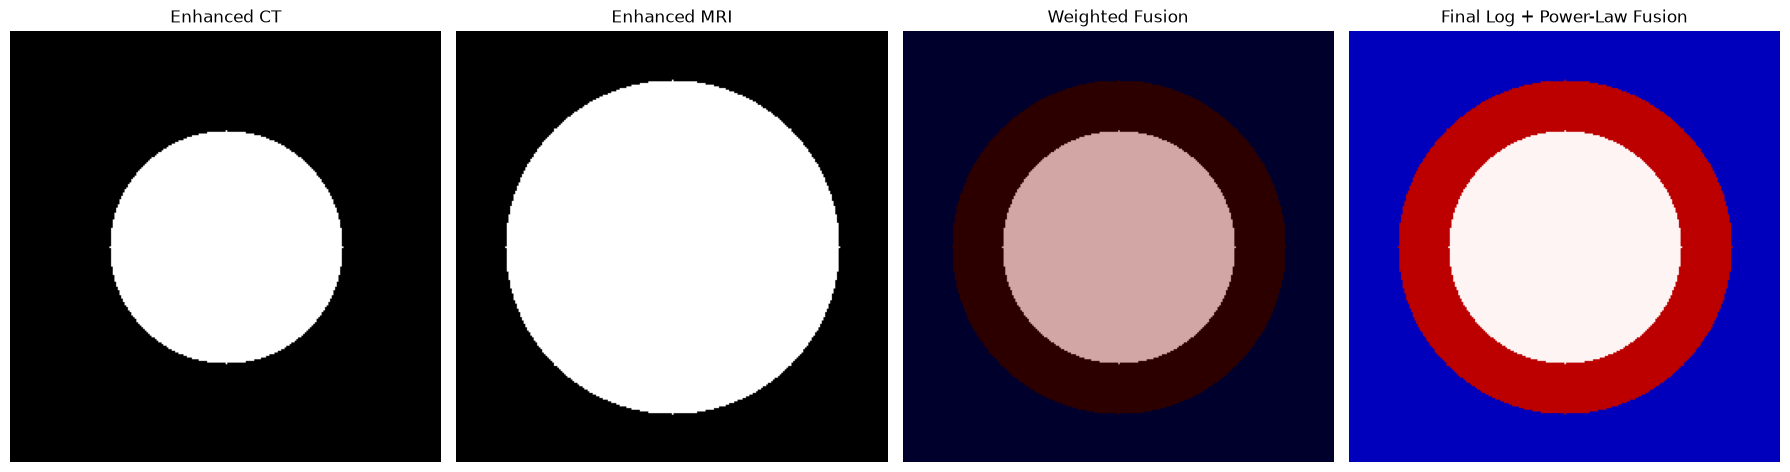

In [5]:
# Save outputs
cv2.imwrite(f"{OUTPUT_DIR}/ct_equalized.png", ct_equalized)
cv2.imwrite(f"{OUTPUT_DIR}/mri_equalized.png", mri_equalized)
cv2.imwrite(f"{OUTPUT_DIR}/weighted_fusion.png", fused)
cv2.imwrite(f"{OUTPUT_DIR}/final_transformed_fusion.png", fused_final)
cv2.imwrite(f"{OUTPUT_DIR}/ct_color_map.png", ct_color)
cv2.imwrite(f"{OUTPUT_DIR}/mri_jet_color_map.png", mri_color)


# 5. Comparative analysis
images = [ct_equalized, mri_equalized, fused, fused_final]
titles = [
    "Enhanced CT", "Enhanced MRI", "Weighted Fusion",
    "Final Log + Power-Law Fusion"
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, image, title in zip(axes, images, titles):
    if image.ndim == 2:
        ax.imshow(image, cmap="gray")
    else:
        ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fusion_comparison.png", dpi=200)
plt.show()